In [ ]:
!pip install -U "huggingface_hub[cli]" hf_xet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 11.0 MB/s  0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.15.0
    Uninstalling huggingface_hub-1.15.0:
      Successfully uninstalled huggingface_hub-1.15.0


In [4]:
!hf download ajimeno/PubTabNet pubtabnet.tar.gz \
  --repo-type dataset \
  --local-dir .

pubtabnet.tar.gz: 100%|████████████████████| 11.2G/11.2G [05:21<00:00, 35.0MB/s]
✓ Downloaded
  path: pubtabnet.tar.gz


In [5]:
!tar -xzf pubtabnet.tar.gz

In [1]:
import os
import json

with open ('./pubtabnet/PubTabNet_2.0.0.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]

In [2]:
#Thống kê số lượng data và các key trong nhãn

print("Number of tables:", len(data))
print("Keys", data[0].keys())
print(data[0]["html"].keys())
print(data[0]["html"]["cells"])
print(data[0]["html"]["structure"])

Number of tables: 509892
Keys dict_keys(['filename', 'split', 'imgid', 'html'])
dict_keys(['cells', 'structure'])
[{'tokens': ['<b>', 'V', 'a', 'r', 'i', 'a', 'b', 'l', 'e', '</b>'], 'bbox': [1, 4, 27, 13]}, {'tokens': ['<b>', 'H', 'a', 'z', 'a', 'r', 'd', ' ', 'r', 'a', 't', 'i', 'o', '</b>'], 'bbox': [219, 4, 260, 13]}, {'tokens': ['<b>', '9', '5', ' ', '%', ' ', 'C', 'I', '</b>'], 'bbox': [336, 4, 363, 13]}, {'tokens': ['<b>', '<i>', 'p', '</i>', ' ', 'v', 'a', 'l', 'u', 'e', '*', '</b>'], 'bbox': [456, 4, 484, 13]}, {'tokens': ['A', 'g', 'e', ' ', '(', 'm', 'e', 'd', 'i', 'a', 'n', ')'], 'bbox': [1, 17, 46, 27]}, {'tokens': []}, {'tokens': []}, {'tokens': ['0', '.', '7', '1', '6'], 'bbox': [456, 17, 475, 27]}, {'tokens': [' ', '≤', '6', '9'], 'bbox': [8, 31, 23, 41]}, {'tokens': ['1', '.', '0', '0', '0'], 'bbox': [219, 31, 238, 41]}, {'tokens': []}, {'tokens': []}, {'tokens': [' ', '>', '6', '9'], 'bbox': [8, 45, 23, 55]}, {'tokens': ['0', '.', '8', '3', '9'], 'bbox': [219, 45, 238

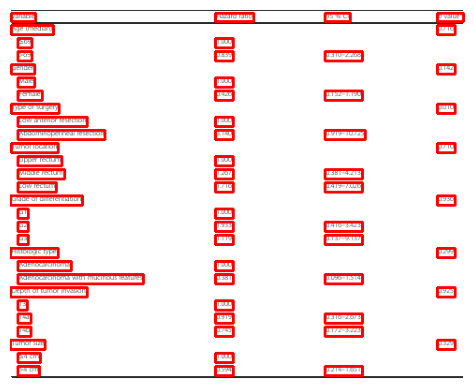

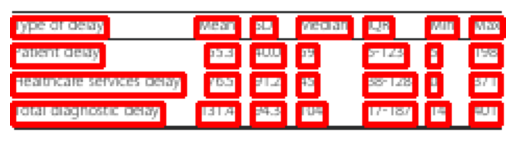

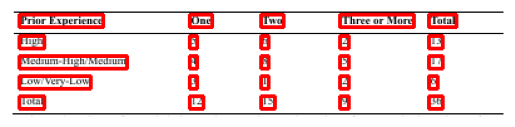

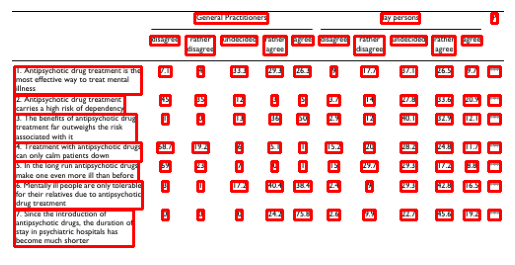

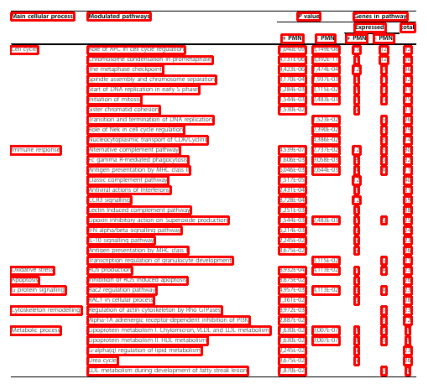

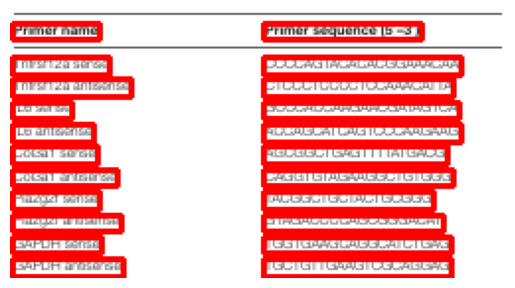

In [3]:
import cv2
import matplotlib.pyplot as plt
for idx, d in enumerate(data):
    image = cv2.imread("pubtabnet/train/" + d["filename"])
    for bbox in d["html"]["cells"]:
        if "bbox" in bbox.keys():
            x1,y1,x2,y2 = bbox["bbox"]
            cv2.rectangle(image, (x1,y1), (x2,y2), thickness=2, color=[255,0,0])
    plt.imshow(image)
    plt.axis("off")
    plt.show()
    if idx==5: break






In [4]:
from pathlib import Path
from collections import Counter, defaultdict
import json, re, math
import pandas as pd

ROOT = Path("/media/drive-2t/hoangnv83/code/3u/graph")
ANN = ROOT / "pubtabnet/PubTabNet_2.0.0.jsonl"

MAX_ROWS = None          # set 20000 để test nhanh trước
CHECK_IMAGES = False     # True sẽ chậm hơn vì đọc ảnh

SPAN_RE = re.compile(r'(rowspan|colspan)="(\d+)"')

def cell_text(tokens):
    return "".join(t for t in tokens if not (t.startswith("<") and t.endswith(">"))).strip()

def parse_structure(tokens):
    rows, spans = [], []
    future = defaultdict(set)
    row, col, in_row = -1, 0, False
    i = 0

    while i < len(tokens):
        t = tokens[i]

        if t == "<tr>":
            row += 1
            col = 0
            in_row = True
            rows.append(set(future.pop(row, set())))
            i += 1
            continue

        if t == "</tr>":
            in_row = False
            i += 1
            continue

        is_cell = (
            in_row and (
                t in ("<td>", "<th>", "<td", "<th")
                or t.startswith("<td ")
                or t.startswith("<th ")
            )
        )

        if is_cell:
            attrs = t
            j = i + 1

            # PubTabNet span tokens can be: "<td", ' colspan="5"', ">"
            if t in ("<td", "<th"):
                while j < len(tokens) and tokens[j] != ">":
                    attrs += tokens[j]
                    j += 1
                i = j

            rowspan, colspan = 1, 1
            for key, value in SPAN_RE.findall(attrs):
                if key == "rowspan":
                    rowspan = int(value)
                elif key == "colspan":
                    colspan = int(value)

            while col in rows[row]:
                col += 1

            for c in range(col, col + colspan):
                rows[row].add(c)

            if rowspan > 1:
                for r in range(row + 1, row + rowspan):
                    for c in range(col, col + colspan):
                        future[r].add(c)

            spans.append((rowspan, colspan))
            col += colspan

        i += 1

    n_rows = len(rows)
    n_cols = max((max(r) + 1 for r in rows if r), default=0)
    return n_rows, n_cols, spans

def image_shape(split, filename):
    if not CHECK_IMAGES:
        return None
    import cv2
    path = ROOT / "pubtabnet" / split / filename
    img = cv2.imread(str(path))
    if img is None:
        return None
    h, w = img.shape[:2]
    return w, h


def difficulty_reasons(row):
    reasons = []
    if row["grid_slots"] >= 120:
        reasons.append("large_grid")
    if row["rows"] >= 20:
        reasons.append("many_rows")
    if row["columns"] >= 10:
        reasons.append("many_columns")
    if row["merged_cells"] > 0:
        reasons.append("merged_cells")
    if row["span_extra_slots"] > 0:
        reasons.append("span_extra_slots")
    if row["empty_cell_rate"] >= 0.25:
        reasons.append("sparse_table")
    if not row["cell_alignment_ok"]:
        reasons.append("structure_alignment_issue")
    if row["missing_bbox_nonempty"] > 0:
        reasons.append("missing_bbox_nonempty")
    if row["invalid_bbox"] > 0:
        reasons.append("invalid_bbox")
    if row["outside_bbox"] > 0:
        reasons.append("outside_bbox")
    return "|".join(reasons)


def difficulty_score(row):
    # Custom EDA heuristic, not an official PubTabNet/FinTabNet metric.
    size_score = math.log1p(max(row["grid_slots"], 0))
    span_score = (
        2.0 * math.log1p(max(row["merged_cells"], 0))
        + 0.5 * math.log1p(max(row["span_extra_slots"], 0))
        + 0.5 * max(row["max_rowspan"] - 1, 0)
        + 0.5 * max(row["max_colspan"] - 1, 0)
    )
    sparsity_score = 2.0 * row["empty_cell_rate"]
    shape_score = (
        1.0 * int(row["rows"] >= 20)
        + 1.0 * int(row["columns"] >= 10)
        + 1.0 * int(row["grid_slots"] >= 120)
    )
    quality_score = (
        1.5 * int(not row["cell_alignment_ok"])
        + 1.0 * int(row["missing_bbox_nonempty"] > 0)
        + 1.0 * int(row["invalid_bbox"] > 0)
        + 1.0 * int(row["outside_bbox"] > 0)
    )
    return size_score + span_score + sparsity_score + shape_score + quality_score


def add_difficulty_columns(df):
    df = df.copy()
    df["difficulty_reasons"] = df.apply(difficulty_reasons, axis=1)
    df["has_difficulty_reason"] = df["difficulty_reasons"].ne("")
    df["difficulty_score"] = df.apply(difficulty_score, axis=1)
    df["difficulty_level"] = "medium"

    for split, idx in df.groupby("split").groups.items():
        scores = df.loc[idx, "difficulty_score"]
        low = scores.quantile(0.33)
        high = scores.quantile(0.67)

        levels = pd.Series("medium", index=idx, dtype="object")
        if low < high:
            levels.loc[scores <= low] = "easy"
            levels.loc[scores >= high] = "hard"
        df.loc[idx, "difficulty_level"] = levels

    return df

records = []
span_counter = Counter()

with ANN.open("r", encoding="utf-8") as f:
    for idx, line in enumerate(f, start=1):
        d = json.loads(line)
        split = d.get("split", "unknown")
        cells = d["html"]["cells"]
        tokens = d["html"]["structure"]["tokens"]

        rows, cols, spans = parse_structure(tokens)

        empty_cells = sum(1 for c in cells if not cell_text(c.get("tokens", [])))
        nonempty_cells = len(cells) - empty_cells
        merged_cells = sum(1 for rs, cs in spans if rs > 1 or cs > 1)
        span_extra_slots = sum(rs * cs - 1 for rs, cs in spans)

        missing_bbox_nonempty = 0
        invalid_bbox = 0
        outside_bbox = 0

        shape = image_shape(split, d["filename"])
        for c in cells:
            txt = cell_text(c.get("tokens", []))
            bbox = c.get("bbox")

            if txt and bbox is None:
                missing_bbox_nonempty += 1

            if bbox is not None:
                ok = (
                    isinstance(bbox, list)
                    and len(bbox) == 4
                    and bbox[2] > bbox[0]
                    and bbox[3] > bbox[1]
                )
                if not ok:
                    invalid_bbox += 1
                elif shape is not None:
                    w, h = shape
                    x1, y1, x2, y2 = bbox
                    if x1 < 0 or y1 < 0 or x2 > w or y2 > h:
                        outside_bbox += 1

        for rs, cs in spans:
            span_counter[(split, rs, cs)] += 1

        records.append({
            "filename": d["filename"],
            "split": split,
            "rows": rows,
            "columns": cols,
            "grid_slots": rows * cols,
            "cells": len(cells),
            "nonempty_cells": nonempty_cells,
            "empty_cells": empty_cells,
            "empty_cell_rate": empty_cells / max(len(cells), 1),
            "merged_cells": merged_cells,
            "merged_cell_rate": merged_cells / max(len(cells), 1),
            "span_extra_slots": span_extra_slots,
            "max_rowspan": max((rs for rs, _ in spans), default=1),
            "max_colspan": max((cs for _, cs in spans), default=1),
            "cell_alignment_ok": len(cells) == len(spans),
            "missing_bbox_nonempty": missing_bbox_nonempty,
            "invalid_bbox": invalid_bbox,
            "outside_bbox": outside_bbox,
        })

        if idx % 50000 == 0:
            print(f"processed {idx:,}")

        if MAX_ROWS and idx >= MAX_ROWS:
            break

df = pd.DataFrame(records)
df = add_difficulty_columns(df)

summary = df.groupby("split").agg(
    tables=("filename", "count"),
    rows_mean=("rows", "mean"),
    rows_p50=("rows", "median"),
    rows_max=("rows", "max"),
    columns_mean=("columns", "mean"),
    columns_p50=("columns", "median"),
    columns_max=("columns", "max"),
    cells_mean=("cells", "mean"),
    cells_max=("cells", "max"),
    empty_cells_sum=("empty_cells", "sum"),
    empty_cell_rate_mean=("empty_cell_rate", "mean"),
    merged_cells_sum=("merged_cells", "sum"),
    merged_cell_rate_mean=("merged_cell_rate", "mean"),
    span_extra_slots_sum=("span_extra_slots", "sum"),
    bad_structure_cells=("cell_alignment_ok", lambda s: (~s).sum()),
    missing_bbox_nonempty_sum=("missing_bbox_nonempty", "sum"),
    invalid_bbox_sum=("invalid_bbox", "sum"),
    outside_bbox_sum=("outside_bbox", "sum"),
    difficult_tables=("has_difficulty_reason", "sum"),
    difficulty_score_mean=("difficulty_score", "mean"),
    difficulty_score_p95=("difficulty_score", lambda s: s.quantile(0.95)),
    difficulty_score_max=("difficulty_score", "max"),
).reset_index()

size_distribution = (
    df.groupby("split")[["rows", "columns", "cells", "grid_slots", "empty_cells", "merged_cells"]]
      .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
)

span_patterns = pd.DataFrame(
    [
        {"split": split, "rowspan": rs, "colspan": cs, "count": count}
        for (split, rs, cs), count in span_counter.items()
    ]
).sort_values(["split", "count"], ascending=[True, False])


span_summary = (
    span_patterns
    .assign(
        rowspan_x_count=lambda d: d["rowspan"] * d["count"],
        colspan_x_count=lambda d: d["colspan"] * d["count"],
    )
    .groupby("split")
    .agg(
        span_cells=("count", "sum"),

        rowspan_min=("rowspan", "min"),
        rowspan_max=("rowspan", "max"),
        rowspan_mean_weighted=("rowspan_x_count", "sum"),

        colspan_min=("colspan", "min"),
        colspan_max=("colspan", "max"),
        colspan_mean_weighted=("colspan_x_count", "sum"),
    )
    .reset_index()
)

span_summary["rowspan_mean_weighted"] = (
    span_summary["rowspan_mean_weighted"] / span_summary["span_cells"]
)

span_summary["colspan_mean_weighted"] = (
    span_summary["colspan_mean_weighted"] / span_summary["span_cells"]
)




image_counts = pd.DataFrame({
    "split": ["train", "val", "test"],
    "image_files": [
        sum(1 for _ in (ROOT / "pubtabnet" / s).glob("*.png"))
        for s in ["train", "val", "test"]
    ],
})


difficulty_distribution = (
    pd.crosstab(df["split"], df["difficulty_level"], normalize="index")
    .round(3)
    .reset_index()
)

top_difficult_tables = (
    df.sort_values("difficulty_score", ascending=False)
    [[
        "split",
        "filename",
        "rows",
        "columns",
        "grid_slots",
        "empty_cells",
        "empty_cell_rate",
        "merged_cells",
        "span_extra_slots",
        "max_rowspan",
        "max_colspan",
        "difficulty_score",
        "difficulty_level",
        "difficulty_reasons",
    ]]
    .head(30)
)

display(summary)
display(size_distribution)
display(span_patterns.groupby("split").head(20))
display(span_summary)
display(image_counts)

display(difficulty_distribution)
display(top_difficult_tables)

processed 50,000
processed 100,000
processed 150,000
processed 200,000
processed 250,000
processed 300,000
processed 350,000
processed 400,000
processed 450,000
processed 500,000


,split,tables,rows_mean,rows_p50,rows_max,columns_mean,columns_p50,columns_max,cells_mean,cells_max,...,merged_cell_rate_mean,span_extra_slots_sum,bad_structure_cells,missing_bbox_nonempty_sum,invalid_bbox_sum,outside_bbox_sum,difficult_tables,difficulty_score_mean,difficulty_score_p95,difficulty_score_max
0,train,500777,14.08901,11.0,89,5.413100,5.0,80,72.297931,2061,...,0.034439,2334402,0,0,0,0,299836,7.277614,15.501107,28.844677
1,val,9115,14.26429,11.0,76,5.474822,5.0,28,74.099506,651,...,0.035956,45252,0,0,0,0,5673,7.477260,15.578061,26.072452


rows                                                              \
          count      mean       std  min  25%   50%   75%   90%   95%   99%   
split                                                                         
train  500777.0  14.08901  9.695523  1.0  7.0  11.0  19.0  28.0  34.0  44.0   
val      9115.0  14.26429  9.785041  2.0  7.0  11.0  19.0  29.0  35.0  45.0   

       ... merged_cells                                                        
       ...         mean       std  min  25%  50%  75%  90%   95%   99%    max  
split  ...                                                                     
train  ...     2.271177  5.131999  0.0  0.0  0.0  3.0  6.0   9.0  22.0  330.0  
val    ...     2.357872  5.166215  0.0  0.0  0.0  3.0  6.0  10.0  20.0  203.0  

[2 rows x 66 columns]

,split,rowspan,colspan,count
0,train,1,1,35067788
4,train,2,1,344205
2,train,1,2,302793
3,train,1,3,122090
7,train,3,1,80794
5,train,1,4,77148
1,train,1,5,53460
6,train,1,6,32547
12,train,4,1,30050
11,train,1,7,27329


,split,span_cells,rowspan_min,rowspan_max,rowspan_mean_weighted,colspan_min,colspan_max,colspan_mean_weighted
0,train,36205141,1,10,1.020998,1,10,1.043241
1,val,675417,1,10,1.020983,1,10,1.045696


,split,image_files
0,train,500777
1,val,9115
2,test,9138


difficulty_level,split,easy,hard,medium
0,train,0.33,0.33,0.34
1,val,0.33,0.33,0.34


,split,filename,rows,columns,grid_slots,empty_cells,empty_cell_rate,merged_cells,span_extra_slots,max_rowspan,max_colspan,difficulty_score,difficulty_level,difficulty_reasons
126929,train,PMC3835321_009_00.png,32,29,928,289,0.561165,300,382,1,8,28.844677,hard,large_grid|many_rows|many_columns|merged_cells...
416718,train,PMC3568713_004_00.png,30,13,390,0,0.000000,66,152,9,10,28.393312,hard,large_grid|many_rows|many_columns|merged_cells...
224015,train,PMC4332945_005_00.png,47,10,470,18,0.056604,108,152,6,10,28.165980,hard,large_grid|many_rows|many_columns|merged_cells...
469286,train,PMC4947836_003_00.png,66,16,1056,431,0.600279,330,338,2,4,27.680984,hard,large_grid|many_rows|many_columns|merged_cells...
100705,train,PMC4422420_004_00.png,43,10,430,49,0.173145,127,147,4,10,27.615065,hard,large_grid|many_rows|many_columns|merged_cells...
290889,train,PMC3798634_004_00.png,51,14,714,177,0.342360,87,99,5,8,27.014261,hard,large_grid|many_rows|many_columns|merged_cells...
159705,train,PMC4204516_006_00.png,62,10,620,3,0.007481,32,219,7,10,26.636123,hard,large_grid|many_rows|many_columns|merged_cells...
176045,train,PMC3788813_003_00.png,36,18,648,114,0.407143,234,332,1,6,26.612961,hard,large_grid|many_rows|many_columns|merged_cells...
287961,train,PMC5303309_005_00.png,40,10,400,72,0.251748,26,114,8,10,26.461598,hard,large_grid|many_rows|many_columns|merged_cells...
346113,train,PMC4494693_004_00.png,31,15,465,50,0.130548,48,82,7,9,26.398343,hard,large_grid|many_rows|many_columns|merged_cells...


Dataset có nhãn bbox-text tương ứng, có struture html (cấu trúc bảng)

In [5]:
display(span_patterns[span_patterns["split"] == "train"])

,split,rowspan,colspan,count
0,train,1,1,35067788
4,train,2,1,344205
2,train,1,2,302793
3,train,1,3,122090
7,train,3,1,80794
5,train,1,4,77148
1,train,1,5,53460
6,train,1,6,32547
12,train,4,1,30050
11,train,1,7,27329


## Selected-feature plots and hard 200 samples

Vẽ đúng 7 thông số đã chốt và trích xuất 200 samples khó cho `pubtabnet`. Manifest được lưu trong folder `pubtabnet_samples`.


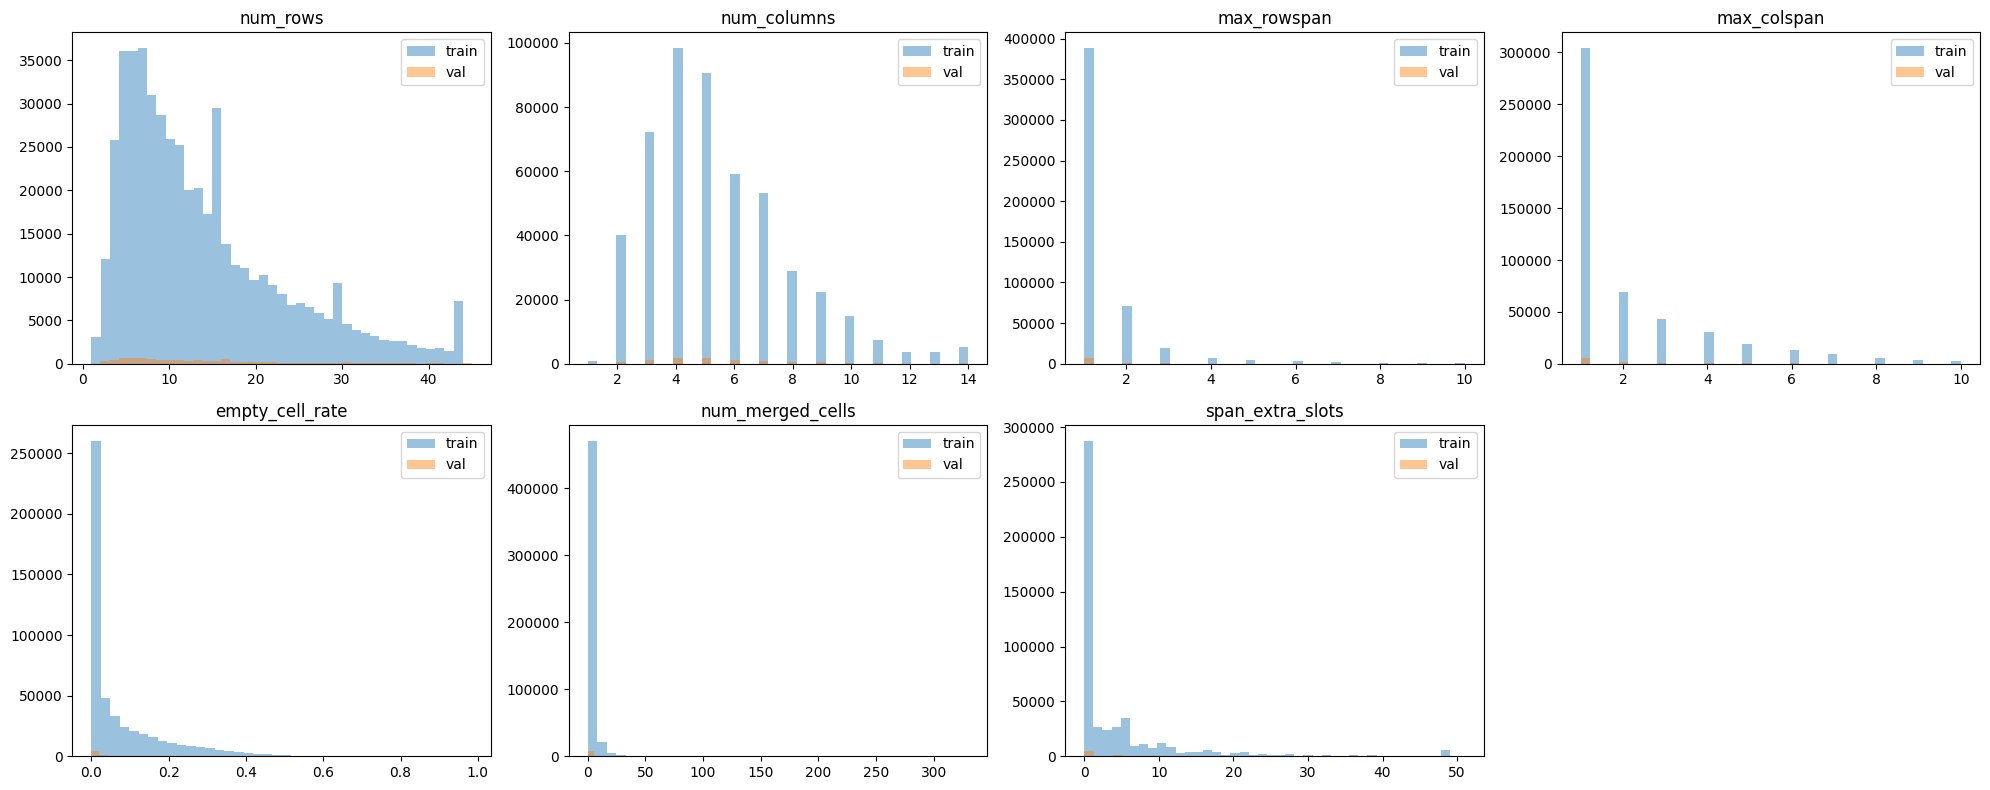

In [6]:
# Visualize only the selected 7 EDA features.
import matplotlib.pyplot as plt

plot_df = df.copy()
plot_df["num_rows"] = plot_df["rows"]
plot_df["num_columns"] = plot_df["columns"]
plot_df["num_merged_cells"] = plot_df["merged_cells"]

plot_cols = [
    "num_rows",
    "num_columns",
    "max_rowspan",
    "max_colspan",
    "empty_cell_rate",
    "num_merged_cells",
    "span_extra_slots",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    for split in sorted(plot_df["split"].unique()):
        values = plot_df.loc[plot_df["split"] == split, col].dropna()
        if col in {"num_rows", "num_columns", "span_extra_slots"} and len(values) > 0:
            values = values.clip(upper=values.quantile(0.99))
        ax.hist(values, bins=40, alpha=0.45, label=split)
    ax.set_title(col)
    ax.legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()


In [7]:
# Extract 200 hard samples using the same 7 selected features.
from pathlib import Path
import math

DATASET_NAME = "pubtabnet"
SAMPLE_OUT_DIR = Path("/media/drive-2t/hoangnv83/code/3u/graph/pubtabnet_samples")
SAMPLE_OUT_DIR.mkdir(parents=True, exist_ok=True)

sample_df = df.copy()
sample_df["num_rows"] = sample_df["rows"]
sample_df["num_columns"] = sample_df["columns"]
sample_df["num_merged_cells"] = sample_df["merged_cells"]
sample_df["empty_cell_rate"] = sample_df["empty_cell_rate"].fillna(0.0)
sample_df["max_rowspan"] = sample_df["max_rowspan"].fillna(1).astype(int)
sample_df["max_colspan"] = sample_df["max_colspan"].fillna(1).astype(int)
sample_df["num_merged_cells"] = sample_df["num_merged_cells"].fillna(0).astype(int)
sample_df["span_extra_slots"] = sample_df["span_extra_slots"].fillna(0).astype(int)

# Stable sample/source ids for manifest export.
if "source_id" not in sample_df.columns:
    sample_df["source_id"] = sample_df["filename"]
sample_df["sample_id"] = sample_df["filename"]


def level_num_rows(num_rows):
    if num_rows <= 5:
        return 0
    if num_rows <= 15:
        return 1
    if num_rows <= 30:
        return 2
    return 3


def level_num_columns(num_columns):
    if num_columns <= 4:
        return 0
    if num_columns <= 8:
        return 1
    if num_columns <= 12:
        return 2
    return 3


def level_rowspan(max_rowspan):
    if max_rowspan <= 1:
        return 0
    if max_rowspan == 2:
        return 1
    if max_rowspan <= 4:
        return 2
    return 3


def level_colspan(max_colspan):
    if max_colspan <= 1:
        return 0
    if max_colspan == 2:
        return 1
    if max_colspan <= 5:
        return 2
    return 3


def level_empty_cell_rate(empty_cell_rate):
    if empty_cell_rate <= 0:
        return 0
    if empty_cell_rate <= 0.10:
        return 1
    if empty_cell_rate <= 0.30:
        return 2
    return 3


def level_num_merged_cells(num_merged_cells):
    if num_merged_cells <= 0:
        return 0
    if num_merged_cells <= 2:
        return 1
    if num_merged_cells <= 5:
        return 2
    return 3


def level_span_extra_slots(span_extra_slots):
    if span_extra_slots <= 0:
        return 0
    if span_extra_slots <= 3:
        return 1
    if span_extra_slots <= 9:
        return 2
    return 3


def difficulty_flags(row):
    flags = []
    if level_num_rows(row["num_rows"]) >= 2:
        flags.append("many_rows")
    if level_num_columns(row["num_columns"]) >= 2:
        flags.append("many_columns")
    if level_rowspan(row["max_rowspan"]) >= 2:
        flags.append("large_rowspan")
    if level_colspan(row["max_colspan"]) >= 2:
        flags.append("large_colspan")
    if level_empty_cell_rate(row["empty_cell_rate"]) >= 2:
        flags.append("many_empty_cells")
    if level_num_merged_cells(row["num_merged_cells"]) >= 2:
        flags.append("many_merged_cells")
    if level_span_extra_slots(row["span_extra_slots"]) >= 2:
        flags.append("complex_span")
    return flags


def difficulty_score(row):
    return (
        1.0 * level_num_rows(row["num_rows"])
        + 1.0 * level_num_columns(row["num_columns"])
        + 1.5 * level_rowspan(row["max_rowspan"])
        + 1.5 * level_colspan(row["max_colspan"])
        + 1.0 * level_empty_cell_rate(row["empty_cell_rate"])
        + 1.5 * level_num_merged_cells(row["num_merged_cells"])
        + 1.5 * level_span_extra_slots(row["span_extra_slots"])
    )


def difficulty_level(score):
    if score < 6:
        return "easy"
    if score < 12:
        return "medium"
    if score < 18:
        return "hard"
    return "very_hard"


sample_df["row_level"] = sample_df["num_rows"].map(level_num_rows)
sample_df["column_level"] = sample_df["num_columns"].map(level_num_columns)
sample_df["rowspan_level"] = sample_df["max_rowspan"].map(level_rowspan)
sample_df["colspan_level"] = sample_df["max_colspan"].map(level_colspan)
sample_df["empty_level"] = sample_df["empty_cell_rate"].map(level_empty_cell_rate)
sample_df["merged_level"] = sample_df["num_merged_cells"].map(level_num_merged_cells)
sample_df["span_extra_level"] = sample_df["span_extra_slots"].map(level_span_extra_slots)
sample_df["difficulty_score"] = sample_df.apply(difficulty_score, axis=1)
sample_df["difficulty_level"] = sample_df["difficulty_score"].map(difficulty_level)
sample_df["difficulty_flags"] = sample_df.apply(lambda row: "|".join(difficulty_flags(row)), axis=1)
sample_df["num_difficulty_flags"] = sample_df["difficulty_flags"].map(lambda x: 0 if not x else len(x.split("|")))


def resolve_split_quotas(existing_splits):
    existing_splits = set(existing_splits)
    quotas = {"train": 140, "val": 40, "test": 20}
    if "val" not in existing_splits and "validation" in existing_splits:
        quotas["validation"] = quotas.pop("val")
    return {split: quota for split, quota in quotas.items() if split in existing_splits}


DIVERSITY_FLAGS = [
    "many_rows",
    "many_columns",
    "large_rowspan",
    "large_colspan",
    "many_empty_cells",
    "many_merged_cells",
    "complex_span",
]


def select_hard_subset_for_split(df, split, quota):
    part = df[df["split"] == split].copy()
    part = part.sort_values(
        ["difficulty_score", "num_difficulty_flags", "num_rows", "num_columns", "num_merged_cells", "span_extra_slots"],
        ascending=[False, False, False, False, False, False],
    )

    top_quota = int(round(quota * 0.70))
    selected = part.head(top_quota).copy()
    selected["selection_reason"] = "top_difficulty_score"
    selected_ids = set(selected["sample_id"])

    remaining_quota = quota - len(selected)
    per_flag = max(1, math.ceil(remaining_quota / len(DIVERSITY_FLAGS)))
    diversity_rows = []

    for flag in DIVERSITY_FLAGS:
        candidates = part[
            part["difficulty_flags"].str.contains(flag, regex=False, na=False)
            & ~part["sample_id"].isin(selected_ids)
        ].head(per_flag).copy()
        candidates["selection_reason"] = flag
        diversity_rows.append(candidates)
        selected_ids.update(candidates["sample_id"])

    if diversity_rows:
        selected = pd.concat([selected] + diversity_rows, ignore_index=True)
        selected = selected.drop_duplicates("sample_id", keep="first")

    if len(selected) < quota:
        fill = part[~part["sample_id"].isin(set(selected["sample_id"]))].head(quota - len(selected)).copy()
        fill["selection_reason"] = "quota_fill_top_score"
        selected = pd.concat([selected, fill], ignore_index=True)

    return selected.head(quota)


split_quotas = resolve_split_quotas(sample_df["split"].unique())
hard_subset_200 = pd.concat(
    [select_hard_subset_for_split(sample_df, split, quota) for split, quota in split_quotas.items()],
    ignore_index=True,
)

manifest_cols = [
    "split",
    "sample_id",
    "source_id",
    "filename",
    "num_rows",
    "num_columns",
    "grid_slots",
    "max_rowspan",
    "max_colspan",
    "empty_cell_rate",
    "num_merged_cells",
    "span_extra_slots",
    "row_level",
    "column_level",
    "rowspan_level",
    "colspan_level",
    "empty_level",
    "merged_level",
    "span_extra_level",
    "difficulty_score",
    "difficulty_level",
    "difficulty_flags",
    "selection_reason",
]

hard_subset_200[manifest_cols].to_csv(SAMPLE_OUT_DIR / f"{DATASET_NAME}_hard_200_manifest.csv", index=False)
hard_subset_200[manifest_cols].to_json(
    SAMPLE_OUT_DIR / f"{DATASET_NAME}_hard_200_manifest.jsonl",
    orient="records",
    lines=True,
    force_ascii=False,
)

print("selected:", len(hard_subset_200))
display(hard_subset_200["split"].value_counts())
display(hard_subset_200["selection_reason"].value_counts())
print("Saved:", SAMPLE_OUT_DIR / f"{DATASET_NAME}_hard_200_manifest.csv")
print("Saved:", SAMPLE_OUT_DIR / f"{DATASET_NAME}_hard_200_manifest.jsonl")

hard_subset_200[manifest_cols].head(20)


selected: 180


split
train    140
val       40
Name: count, dtype: int64

selection_reason
top_difficulty_score    126
many_rows                 8
many_columns              8
large_rowspan             8
large_colspan             8
many_empty_cells          8
many_merged_cells         8
complex_span              6
Name: count, dtype: int64

Saved: /media/drive-2t/hoangnv83/code/3u/graph/pubtabnet_samples/pubtabnet_hard_200_manifest.csv
Saved: /media/drive-2t/hoangnv83/code/3u/graph/pubtabnet_samples/pubtabnet_hard_200_manifest.jsonl


,split,sample_id,source_id,filename,num_rows,num_columns,grid_slots,max_rowspan,max_colspan,empty_cell_rate,...,column_level,rowspan_level,colspan_level,empty_level,merged_level,span_extra_level,difficulty_score,difficulty_level,difficulty_flags,selection_reason
0,train,PMC3798634_004_00.png,PMC3798634_004_00.png,PMC3798634_004_00.png,51,14,714,5,8,0.342360,...,3,3,3,3,3,3,27.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score
1,train,PMC3461145_005_00.png,PMC3461145_005_00.png,PMC3461145_005_00.png,41,13,533,8,7,0.333333,...,3,3,3,3,3,3,27.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score
2,train,PMC2234387_002_00.png,PMC2234387_002_00.png,PMC2234387_002_00.png,46,9,414,5,9,0.326446,...,2,3,3,3,3,3,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score
3,train,PMC5120444_007_00.png,PMC5120444_007_00.png,PMC5120444_007_00.png,37,11,407,5,9,0.327434,...,2,3,3,3,3,3,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score
4,train,PMC5112882_004_00.png,PMC5112882_004_00.png,PMC5112882_004_00.png,35,10,350,8,7,0.344828,...,2,3,3,3,3,3,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score
5,train,PMC4210966_005_00.png,PMC4210966_005_00.png,PMC4210966_005_00.png,34,10,340,6,6,0.361446,...,2,3,3,3,3,3,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score
6,train,PMC4015127_003_00.png,PMC4015127_003_00.png,PMC4015127_003_00.png,32,13,416,6,7,0.107143,...,3,3,3,2,3,3,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score
7,train,PMC4494693_004_00.png,PMC4494693_004_00.png,PMC4494693_004_00.png,31,15,465,7,9,0.130548,...,3,3,3,2,3,3,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score
8,train,PMC5514508_006_00.png,PMC5514508_006_00.png,PMC5514508_006_00.png,31,14,434,7,6,0.107143,...,3,3,3,2,3,3,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score
9,train,PMC5514508_003_00.png,PMC5514508_003_00.png,PMC5514508_003_00.png,31,14,434,8,6,0.103896,...,3,3,3,2,3,3,26.0,very_hard,many_rows|many_columns|large_rowspan|large_col...,top_difficulty_score
